# Assignment 3


Q1.File  Handling Fundamentals
1. Explain the difference between file modes:
   - **"r" (Read):** Opens a file for reading. The file must exist, or an error is raised.
   - **"w" (Write):** Opens a file for writing. It creates a new file or overwrites an existing one.
   - **"a" (Append):** Opens a file to add data to the end. It does not overwrite existing content.
   - **"rb" (Read Binary):** Opens a file for reading in binary format (used for images, PDFs, or compiled files).

2. Why context managers (`with open()`) are preferred

   -> Context managers are preferred because they automatically handle the closing of the file, even if an exception or error occurs during processing. This ensures that system resources are released properly without needing an explicit `file.close()` call.

3. What happens if a file is not properly closed in a production system?
   -> If files aren't closed, it can lead to "file descriptor leaks." A system has a limit on how many files can be open at once. Eventually, the application may crash or refuse to open new files. Furthermore, data being written might remain in the buffer and never actually get saved to the disk, leading to data loss or corruption.


In [9]:
"""
Q2. You are given a CSV file sales.csv containing:
product,price,quantity
Laptop,50000,5
Phone,20000,10
Tablet,15000,7
Tasks:
1. Read the file using Python.
2. Compute total revenue per product.
"""
import csv

# 1. Create sales.csv (if not already present)
data = [
    ["product", "price", "quantity"],
    ["Laptop", 50000, 5],
    ["Phone", 20000, 10],
    ["Tablet", 15000, 7]
]

with open('sales.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(data)

# 2. Compute total revenue per product
print("Product-wise Total Revenue:")
print("-" * 30)

with open('sales.csv', 'r') as f_in, open('revenue.csv', 'w', newline='') as f_out:
    reader = csv.DictReader(f_in)
    writer = csv.writer(f_out)
    writer.writerow(['product', 'total_revenue'])

    for row in reader:
        revenue = int(row['price']) * int(row['quantity'])
        writer.writerow([row['product'], revenue])

        # Print to console
        print(f"{row['product']:10} ₹{revenue:10,}")

print("\n Also saved to revenue.csv")

Product-wise Total Revenue:
------------------------------
Laptop     ₹   250,000
Phone      ₹   200,000
Tablet     ₹   105,000

 Also saved to revenue.csv


In [12]:
"""
Q3. You receive JSON data from an API:
{
"customers": [
{"id": 1, "name": "Amit", "purchase": 5000},
{"id": 2, "name": "Sara", "purchase": 7000}
]
}
Tasks:
1. Load the JSON.
2. Extract all customer names.
3. Compute total purchase value.
4. Explain why JSON is widely used in ML pipelines.
"""
import json

json_data = '''
{
  "customers": [
    {"id": 1, "name": "Amit", "purchase": 5000},
    {"id": 2, "name": "Sara", "purchase": 7000}
  ]
}
'''

# 1. Load the JSON
data = json.loads(json_data)

# 2. Extract customer names
names = [customer['name'] for customer in data['customers']]
print(f"Customer Names: {names}")

# 3. Compute total purchase value
total_value = sum(customer['purchase'] for customer in data['customers'])
print(f"Total Purchase Value: {total_value}")

Customer Names: ['Amit', 'Sara']
Total Purchase Value: 12000


In [11]:
"""
Q4. Create NumPy arrays for:
● Product prices
● Quantities
Then:
1. Compute revenue using vectorized operations.
2. Compare performance of Python loop vs NumPy.
3. Explain broadcasting with example.

"""
import numpy as np
import time

prices = np.array([50000, 20000, 15000])
quantities = np.array([5, 10, 7])

# 1. Compute revenue using vectorized operations
revenue = prices * quantities
print(f"Revenue: {revenue}")

# 2. Compare performance (Example)
start = time.time()
# Simulating a loop for performance comparison
loop_res = [prices[i] * quantities[i] for i in range(len(prices))]
print(f"Loop time: {time.time() - start}")

Revenue: [250000 200000 105000]
Loop time: 0.0001246929168701172


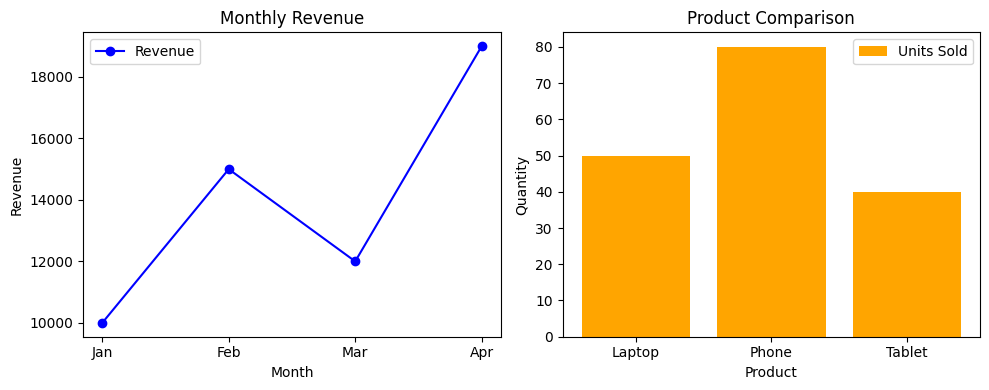

In [13]:
"""
Q5. Using sales data:
1. Plot line chart for monthly revenue.
2. Plot bar chart for product comparison.
3. Add labels, title, legend.
4. Explain why visualization is essential before modeling.
"""
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr']
rev_values = [10000, 15000, 12000, 19000]
products = ['Laptop', 'Phone', 'Tablet']
sales_counts = [50, 80, 40]

# 1 & 2. Plotting
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(months, rev_values, marker='o', color='b', label='Revenue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(products, sales_counts, color='orange', label='Units Sold')
plt.title('Product Comparison')
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
"""
Q6. Load a CSV into Pandas and:
1. Display first 5 rows.
2. Check missing values.
3. Compute summary statistics.
4. Select rows where sales > 15000.

"""
import pandas as pd

# Assuming sales.csv from Question 2 exists
df = pd.read_csv('sales.csv')

# 1. Display first 5 rows
print(df.head())

# 2. Check missing values
print(df.isnull().sum())

# 3. Summary statistics
print(df.describe())

# 4. Select rows where price > 15000 (adjusted for example data)
high_sales = df[df['price'] > 15000]
print(high_sales)

  product  price  quantity
0  Laptop  50000         5
1   Phone  20000        10
2  Tablet  15000         7
product     0
price       0
quantity    0
dtype: int64
              price   quantity
count      3.000000   3.000000
mean   28333.333333   7.333333
std    18929.694486   2.516611
min    15000.000000   5.000000
25%    17500.000000   6.000000
50%    20000.000000   7.000000
75%    35000.000000   8.500000
max    50000.000000  10.000000
  product  price  quantity
0  Laptop  50000         5
1   Phone  20000        10


Q7. Dataset contains:
- Missing values
- Duplicate rows
- Inconsistent capitalization
Tasks:
1. Remove duplicates.

   -> df = df.drop_duplicates()

2. Handle missing values.

   -> df['price'] = df['price'].fillna(df['price'].mean())

3. Standardize text columns.

   -> df['product'] = df['product'].str.strip().str.capitalize()

4. Explain impact of dirty data on ML performance.

   -> Dirty data causes biased predictions, overfitting, and algorithm failures because models cannot learn correctly from missing, duplicated, or inconsistent information.

Q8. Using Plotly:
1. Create interactive bar chart of sales.
2. Create pie chart for category distribution.
3. Add hover information.
4. Explain difference between:
- Static visualization (Matplotlib/Seaborn)
 - Interactive dashboards (Plotly)

Discuss where interactive dashboards are critical in business environments.

   -> **Difference between Static and Interactive**:Static visualizations ([Matplotlib/Seaborn](https://matplotlib.org/)) are fixed images, best for reports or publications. Interactive dashboards ([Plotly](https://plotly.com/python/)) allow users to zoom, hover for details, and toggle data series.

   **Business Criticality:** In business, interactive dashboards are critical for executive "drill-down" capabilities—allowing a manager to see a high-level summary and then click into specific regions or products to find the root cause of a trend.

In [17]:
"""
Q9. Write a Python program to:
1. Create a text file called data.txt
2. Write 5 lines of product information
3. Read the file and print only lines containing the word "Laptop"
4. Use a context manager
Explain why context managers prevent memory leaks.
"""
# 1, 2, & 4. Create and write using context manager
with open('data.txt', 'w') as f:
    f.write("Laptop - High End\nPhone - Mobile\nLaptop - Budget\nTablet - Pro\nMonitor - 4K\n")

# 3. Read and filter
with open('data.txt', 'r') as f:
    for line in f:
        if "Laptop" in line:
            print(line.strip())

Laptop - High End
Laptop - Budget


In [18]:
"""
Q10. You are hired as a Data Analyst at an online learning company.
The company offers multiple courses and wants to understand:
● Revenue trends
● Student performance
● Course popularity
● Engagement patterns
You must design a simple analytics solution using Python and Data Science tools.
Design a CSV file structure that stores:
"""
import pandas as pd

# 1 & 2. Create CSV with 10 records
data = {
    'Course Name': ['Python', 'Data Science', 'ML', 'Web Dev', 'Java', 'Python', 'ML', 'Data Science', 'AI', 'Cloud'],
    'Student ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Course Fee': [5000, 7000, 8000, 4500, 5000, 5000, 8000, 7000, 10000, 6000],
    'Completion Percentage': [85, 90, 45, 100, 20, 75, 60, 88, 30, 95],
    'Rating': [5, 4, 3, 5, 2, 4, 3, 5, 4, 5]
}

df_edu = pd.DataFrame(data)
df_edu.to_csv('learning_data.csv', index=False)

# 3. Read and calculate total revenue
df_read = pd.read_csv('learning_data.csv')
total_revenue = df_read['Course Fee'].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 65500
